# **Tugas Kecerdasan Komputasional Praktikum 4**
Faiz Muhammad Kautsar  
5054231013 (RKA)  
Inferensi, NRP Ganjil, dengan `tt_entails`.

<a target="_blank" href="https://colab.research.google.com/drive/1gHtJX-uFm5Al_lDgdRn9ZpxpaYxM2F8K?usp=sharing">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

N.B. karena beberapa konsep telah saya eksplorasi di tugas sebelumnya, di sini saya *copy* saja section-section tersebut. Beberapa saya collapse pula agar bisa di-print notebooknya, untuk full notebook bisa dicek di link di atas ("Open In Colab").

# ***Project Setup***
Untuk *setup*, saya meng-clone repo git dari [sini](https://github.com/bscpnu/Praktikum-Kecerdasan-Komputasional) lalu mengganti direktori dari kernel agar menuju ke direktori repo.

Instalasi `ipythonblocks` dan `qpsolvers` dilakukan karena merupakan *dependency* dari *utility* AIMA yang digunakan.

Saya definisi kembali *utility* `psource` agar kompatibel dengan dark mode.

In [12]:
!sudo apt install git

Sudo is disabled on this machine. To enable it, go to the ]8;;ms-settings:developers\Developer Settings page]8;;\ in the Settings app


In [13]:
!pip install ipythonblocks
!pip install qpsolvers
!pip install catppuccin
!pip install catppuccin[pygments]
!pip install tabulate

In [14]:
%cd /content
!git clone https://github.com/bscpnu/Praktikum-Kecerdasan-Komputasional

[WinError 2] The system cannot find the file specified: '/content'
d:\AI_Journey\Computational_Intelligence\College_CI\praktikum kuliah\main\Praktikum\2 - Logical Agents
^C


Cloning into 'Praktikum-Kecerdasan-Komputasional'...


In [ ]:
%cd "/content/Praktikum-Kecerdasan-Komputasional/Praktikum/2 - Logical Agents"

In [ ]:
!mv "/content/Praktikum-Kecerdasan-Komputasional/aima-data" "/content/Praktikum-Kecerdasan-Komputasional/Praktikum/2 - Logical Agents"

In [15]:
from utils import *
from logic import *
import agents
import math
from inspect import getsource
from IPython.display import HTML
from tabulate import tabulate

In [16]:
def psource(*functions):
    """Print the source code for the given function(s)."""
    source_code = '\n\n'.join(getsource(fn) for fn in functions)
    try:
        from pygments.formatters import HtmlFormatter
        from pygments.lexers import PythonLexer
        from pygments import highlight

        formatter = HtmlFormatter(
            full=True,
            style='catppuccin-mocha',
            noclasses=True,
        )
        display(HTML(highlight(source_code, PythonLexer(), formatter)))

    except ImportError:
        print(source_code)

# ***Code***

## **WumpusAgent**

Untuk menyelesaikan penugasan ini, saya mendefine sebuah class agent `WumpusAgent`. Agent ini akan mengeksplorasi sample case dengan cara *Depth-First Search* (DFS) dengan inferensi menggunakan `tt_entails`.

Inisialisasi class menerima 3 buah argumen:
1. **world:** List 3 level, level 1 untuk axis vertikal, level 2 untuk axis horizontal, level 3 untuk konten tiap cell.
2. **initial_pos:** Posisi awal, dalam bentuk tuple.
3. **break_on_find:** Boolean, menentukan apakah berhenti ketika menemukan gold.

Dalam eksplorasi map, agent akan DFS melalui fungsi `dfs()`. Fungsi `dfs()` menentukan adjacent neighbor untuk dikunjungi (i.e., ditambahkan ke stack) berdasarkan konvergensi sebuah cell terhadap state Safe di KB.

Flow dari implementasi DFS saya adalah sebagai berikut:
1. Di inisialisasi, kita set terlebih dahulu posisi awal sebagai Safe ke dalam KB. Posisi awal kita tambahkan ke stack.
2. Kemudian, selama masih ada isi stack, kita `pop()` lalu kita kunjungi cell tersebut, selama belum kita kunjungi sebelumnya:
   1. Kita ambil percept dari cell ini serta semua cell di sekeliling/adjacent (horizontal dan vertikal)nya. Kita tambahkan hasil percept-percept tersebut ke dalam KB. Penambahan percept adalah sebagai berikut:
        - Untuk Breeze, Gold, dan Stench di cell saat ini langsung kita tambahkan ke KB dengan format `{percept}({x},{y})`.
        - Untuk cell Breeze, kita tambahkan `P({nx},{ny})` dengan nx,ny tiap-tiap adjacent dihubungkan dengan operator OR.
        - Untuk cell Stench, kita tambahkan `W({nx},{ny})` dengan nx,ny tiap-tiap adjacent dihubungkan dengan operator OR.
   2. Kita iterasi semua cell adjacent dari cell kemudian kita query ke KB untuk status dari tiap-tiap cell adjacent tersebut. Berikut adalah pengecekan yang saya lakukan untuk tiap cell:
        - Pertama kita cek dahulu array dari klausa dalam KB apakah berisi Pit atau Wumpus di cell tersebut, di sini saya cek manual seperti ini karena jika kita langsung enumerasi TT akan terlalu lambat untuk cell-cell yang tidak langsung berkonvergensi pada state non-Safe, karena perlu evaluasi keseluruhan TT hingga tautologi.
    
        N.B., sebenarnya jika kita inferensi menggunakan resolution akan jauh lebih cepat, bisa tanpa ini, dan langsung ke pengecekan selanjutnya, akan tetapi karena saya diberi penugasan untuk menggunakan `tt_entails`, perlu diimplementasikan optimasi ini untuk memastikan bisa dijalankannya solusi.

        - Kemudian, jika tidak secara eksplisit telah terdefinisi sebagai non-Safe pada KB, akan dilakukan inferensi pada KB dengan method `ask_if_true`, inferensi ini meng-wrap `tt_entails` di dalamnya.

        - Jika semua yang di atas tidak terpenuhi, bisa kita asumsikan bahwa cell Safe. Semua cell Safe kemudian kita tambahkan ke stack.

   3. Jika cell saat ini Gold, jika `break_on_find=True` maka kita break, jika tidak, while akan berjalan terus hingga stack habis.

Pada tiap iterasi, saya tambahkan *utility* `print_world_perception` untuk menunjukan persepsi agent tentang world sample case saat ini, fungsi ini menggunakan `tabulate()` untuk membuat grid dan langsung mengecek isi KB untuk visualisasi (i.e., tanpa inferensi).

In [17]:
class WumpusAgent:
    def __init__(self, world, initial_pos, break_on_find=True):
        initial_pos = tuple(initial_pos)
        self.world = world
        self.kb = PropKB()
        self.visited = set()
        self.break_on_find = break_on_find
        self.current_position = initial_pos
        self.directions = [(0, 1), (1, 0), (0, -1), (-1, 0)]  # Up, Right, Down, Left
        self.gold_found = False
        self.gold_position = None

        # Set the starting point as safe
        self.kb.tell(expr(f"Safe({initial_pos[0]},{initial_pos[1]})"))
        self.visited.add(initial_pos)
        self.update_kb(initial_pos[0], initial_pos[1])

    def get_percepts(self, x, y):
      world_x = len(self.world) - y
      world_y = x - 1
      if 0 <= world_x < len(self.world) and 0 <= world_y < len(self.world[0]):
          return set(self.world[world_x][world_y])
      return set()

    def update_kb(self, x, y):
        percepts = self.get_percepts(x, y)
        self.kb.tell(expr(f"Safe({x},{y})"))
        print(f"Updating KB for ({x},{y}):")
        for percept in percepts:
            self.kb.tell(expr(f"{percept}({x},{y})"))
            print(f"  - Added {percept}({x},{y}) to KB")
            if percept == "B":
                adjacent_expr = " | ".join([f"P({nx},{ny})" for nx, ny in self.adjacent_cells(x, y)])
                self.kb.tell(expr(adjacent_expr))
                print(f"  - Added {adjacent_expr} to KB due to Breeze")
            if percept == "S":
                adjacent_expr = " | ".join([f"W({nx},{ny})" for nx, ny in self.adjacent_cells(x, y)])
                self.kb.tell(expr(adjacent_expr))
                print(f"  - Added {adjacent_expr} to KB due to Stench")
            if percept == "G":
                self.gold_found = True
                self.gold_position = (x, y)
                print(f"Gold found at position ({x},{y})!")

        # Update KB with percepts from adjacent cells
        for nx, ny in self.adjacent_cells(x, y):
            adj_percepts = self.get_percepts(nx, ny)
            if not adj_percepts:
                self.kb.tell(expr(f"Safe({nx},{ny})"))
                print(f"  - Added Safe({nx},{ny}) to KB (adjacent cell)")
            for percept in adj_percepts:
                self.kb.tell(expr(f"{percept}({nx},{ny})"))
                print(f"  - Added {percept}({nx},{ny}) to KB (adjacent cell)")


    def is_safe(self, x, y):
      if expr(f"P({x},{y})") in self.kb.clauses:
          return False, "contains a pit"
      if expr(f"W({x},{y})") in self.kb.clauses:
          return False, "contains a wumpus"
      if (expr(f"P({x},{y})") not in self.kb.clauses and expr(f"W({x},{y})") not in self.kb.clauses) or (self.kb.ask_if_true(expr(f"Safe({x},{y})"))):
          return True, "known to be safe"
      if self.kb.ask_if_true(expr(f"P({x},{y})")):
          return False, "might contain a pit"
      if  self.kb.ask_if_true(expr(f"W({x},{y})")):
          return False, "might contain a wumpus"
      # If KB doesn't conclude P or W, it's safe to visit
      return True, "no conclusive danger in KB"

    def adjacent_cells(self, x, y):
        return [(x + dx, y + dy) for dx, dy in self.directions
                if 1 <= x + dx <= len(self.world[0]) and 1 <= y + dy <= len(self.world)]

    def print_world_perception(self):
            world_perception = []
            for y in range(len(self.world), 0, -1):  # Start from top row
                row = []
                for x in range(1, len(self.world[0]) + 1):
                    cell_info = []
                    if (x, y) in self.visited:
                        cell_info.append("V")
                    if expr(f"Safe({x},{y})") in self.kb.clauses:
                        cell_info.append("Sf")
                    if expr(f"P({x},{y})") in self.kb.clauses:
                        cell_info.append("P")
                    if expr(f"W({x},{y})") in self.kb.clauses:
                        cell_info.append("W")
                    if expr(f"B({x},{y})") in self.kb.clauses:
                        cell_info.append("B")
                    if expr(f"S({x},{y})") in self.kb.clauses:
                        cell_info.append("S")
                    if (x, y) == self.gold_position:
                        cell_info.append("\n<G>")
                    row.append(("[A]\n" if (x, y) == self.current_position else "") + (",".join(cell_info) if cell_info else "?"))
                world_perception.append(row)

            headers = [str(i) for i in range(1, len(self.world[0]) + 1)]
            print("\nAgent's World Perception:")
            print(tabulate(world_perception, headers=headers, showindex=range(len(self.world), 0, -1), tablefmt="rounded_grid"))


    def dfs(self):
        print("DFS Search:")
        print(f"Starting at position ({self.current_position[0]},{self.current_position[1]})")
        self.print_world_perception()
        stack = []
        iteration = 1
        for nx, ny in self.adjacent_cells(self.current_position[0], self.current_position[1]):
            is_safe, reason = self.is_safe(nx, ny)
            if is_safe:
                stack.append((nx, ny))
                print(f"  Added ({nx},{ny}) to stack because it's {reason}")

        while stack:
            print(f"\nIteration {iteration}", end="")
            iteration += 1
            print(f"\nStack: {stack}")
            x, y = stack.pop()
            print(f"\nConsidering position ({x},{y}):")
            is_safe, reason = self.is_safe(x, y)
            if (x, y) not in self.visited and is_safe:
                print(f"  Visiting ({x},{y}) because it's {reason}")
                self.visited.add((x, y))
                self.current_position = (x, y)
                self.update_kb(x, y)

                print(f"Visited ({x},{y})")
                print(f"Current KB: {self.kb.clauses}")

                self.print_world_perception()

                if self.break_on_find and self.gold_found:
                    break

                adjacent = self.adjacent_cells(x, y)
                adjacent.sort(key=lambda pos: (pos[1], pos[0]), reverse=True)

                print("Considering adjacent cells:")
                for next_x, next_y in adjacent:
                    print(f"Evaluating ({next_x},{next_y}):")
                    if (next_x, next_y) in self.visited:
                        print(f"  Skipped ({next_x},{next_y}) because it has already been visited")
                    else:
                        is_safe, reason = self.is_safe(next_x, next_y)
                        if is_safe:
                            stack.append((next_x, next_y))
                            print(f"  Added ({next_x},{next_y}) to stack because it's {reason}")
                        else:
                            print(f"  Skipped ({next_x},{next_y}) because it {reason}")
            else:
                if (x, y) in self.visited:
                    print(f"  Skipped ({x},{y}) because it has already been visited")
                else:
                    print(f"  Skipped ({x},{y}) because it {reason}")

        if self.gold_found:
            print(f"\nSearch completed. Gold was found at ({self.gold_position[0]},{self.gold_position[1]}).")
        else:
            print("\nSearch completed. Gold was not found.")
        print(f"Final position: ({self.current_position[0]},{self.current_position[1]})")
        self.print_world_perception()

### **Hasil Testing**

#### **Sample 1**

Sample ini saya ambil dari penugasan.

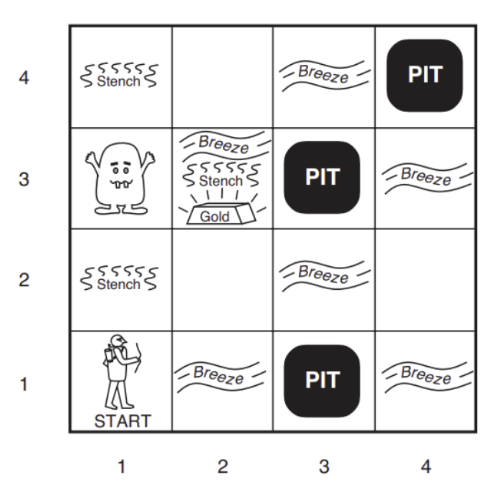

In [18]:
world = [
    [["S"], [], ["B"], ["P"]],
    [["W"], ["S", "B", "G"], ["P"], ["B"]],
    [["S"], [], ["B"], []],
    [[], ["B"], ["P"], ["B"]]
]

agent = WumpusAgent(world, (1, 1), False)
agent.dfs()

Updating KB for (1,1):
  - Added S(1,2) to KB (adjacent cell)
  - Added B(2,1) to KB (adjacent cell)
DFS Search:
Starting at position (1,1)

Agent's World Perception:
╭────┬──────┬─────┬─────┬─────╮
│    │ 1    │ 2   │ 3   │ 4   │
├────┼──────┼─────┼─────┼─────┤
│  4 │ ?    │ ?   │ ?   │ ?   │
├────┼──────┼─────┼─────┼─────┤
│  3 │ ?    │ ?   │ ?   │ ?   │
├────┼──────┼─────┼─────┼─────┤
│  2 │ S    │ ?   │ ?   │ ?   │
├────┼──────┼─────┼─────┼─────┤
│  1 │ [A]  │ B   │ ?   │ ?   │
│    │ V,Sf │     │     │     │
╰────┴──────┴─────┴─────┴─────╯
  Added (1,2) to stack because it's known to be safe
  Added (2,1) to stack because it's known to be safe

Iteration 1
Stack: [(1, 2), (2, 1)]

Considering position (2,1):
  Visiting (2,1) because it's known to be safe
Updating KB for (2,1):
  - Added B(2,1) to KB
  - Added P(2,2) | P(3,1) | P(1,1) to KB due to Breeze
  - Added Safe(2,2) to KB (adjacent cell)
  - Added P(3,1) to KB (adjacent cell)
  - Added Safe(1,1) to KB (adjacent cell)
Visite

#### **Sample 2**

Sample ini saya ambil dari penugasan lalu saya modifikasi jadi $5\times4$ dengan tambahan 1 pit.

In [19]:
world = [
    [["S"], [], ["B"], ["P"], ["B"]],
    [["W"], ["S", "B", "G"], ["P"], ["B"], ["P"]],
    [["S"], [], ["B"], [], ["B"]],
    [[], ["B"], ["P"], ["B"], []]
]

agent = WumpusAgent(world, (5, 1), False)
agent.dfs()

Updating KB for (5,1):
  - Added B(5,2) to KB (adjacent cell)
  - Added B(4,1) to KB (adjacent cell)
DFS Search:
Starting at position (5,1)

Agent's World Perception:
╭────┬─────┬─────┬─────┬─────┬──────╮
│    │ 1   │ 2   │ 3   │ 4   │ 5    │
├────┼─────┼─────┼─────┼─────┼──────┤
│  4 │ ?   │ ?   │ ?   │ ?   │ ?    │
├────┼─────┼─────┼─────┼─────┼──────┤
│  3 │ ?   │ ?   │ ?   │ ?   │ ?    │
├────┼─────┼─────┼─────┼─────┼──────┤
│  2 │ ?   │ ?   │ ?   │ ?   │ B    │
├────┼─────┼─────┼─────┼─────┼──────┤
│  1 │ ?   │ ?   │ ?   │ B   │ [A]  │
│    │     │     │     │     │ V,Sf │
╰────┴─────┴─────┴─────┴─────┴──────╯
  Added (5,2) to stack because it's known to be safe
  Added (4,1) to stack because it's known to be safe

Iteration 1
Stack: [(5, 2), (4, 1)]

Considering position (4,1):
  Visiting (4,1) because it's known to be safe
Updating KB for (4,1):
  - Added B(4,1) to KB
  - Added P(4,2) | P(5,1) | P(3,1) to KB due to Breeze
  - Added Safe(4,2) to KB (adjacent cell)
  - Added Safe(